In [95]:
import xgboost
print(xgboost.__version__)


3.1.2


In [96]:
import pandas as pd
import numpy as np
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [97]:
print(df.info())
print(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [98]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors='coerce')

In [99]:
missing_percent = df.isnull().mean() * 100
print(missing_percent[missing_percent > 0])

TotalCharges    0.156183
dtype: float64


In [100]:
df = df.dropna(subset=["TotalCharges"])

In [101]:
missing_percent = df.isnull().mean() * 100
print(missing_percent[missing_percent > 0])

Series([], dtype: float64)


In [102]:
print(df.info())
print(df.head())

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   object 
 1   gender            7032 non-null   object 
 2   SeniorCitizen     7032 non-null   int64  
 3   Partner           7032 non-null   object 
 4   Dependents        7032 non-null   object 
 5   tenure            7032 non-null   int64  
 6   PhoneService      7032 non-null   object 
 7   MultipleLines     7032 non-null   object 
 8   InternetService   7032 non-null   object 
 9   OnlineSecurity    7032 non-null   object 
 10  OnlineBackup      7032 non-null   object 
 11  DeviceProtection  7032 non-null   object 
 12  TechSupport       7032 non-null   object 
 13  StreamingTV       7032 non-null   object 
 14  StreamingMovies   7032 non-null   object 
 15  Contract          7032 non-null   object 
 16  PaperlessBilling  7032 non-null   object 
 17  

In [103]:
df.duplicated().sum()

np.int64(0)

In [104]:
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

In [105]:
print(df['Churn'].value_counts())
print(df['Churn'].head())

Churn
0    5163
1    1869
Name: count, dtype: int64
0    0
1    0
2    1
3    0
4    1
Name: Churn, dtype: int64


In [106]:
df = df.drop(columns=['customerID'])

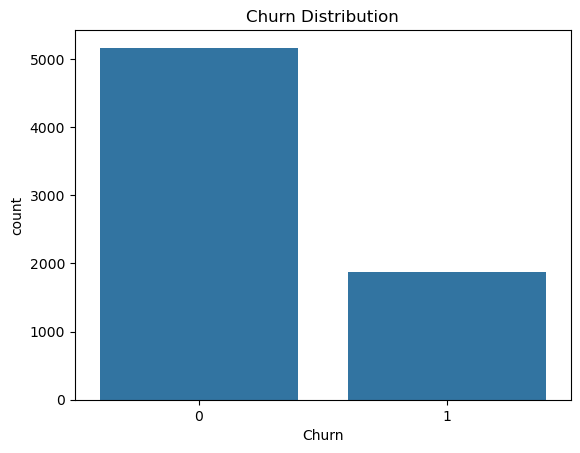

In [107]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.countplot(x='Churn', data=df)
plt.title('Churn Distribution')
plt.show()

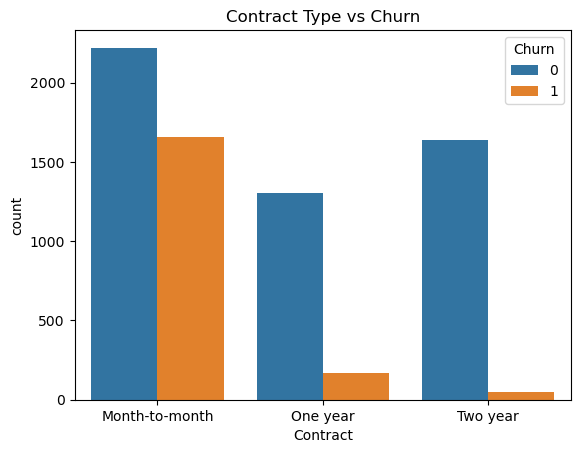

In [108]:
sns.countplot(x='Contract', hue='Churn', data=df)
plt.title('Contract Type vs Churn')
plt.show()


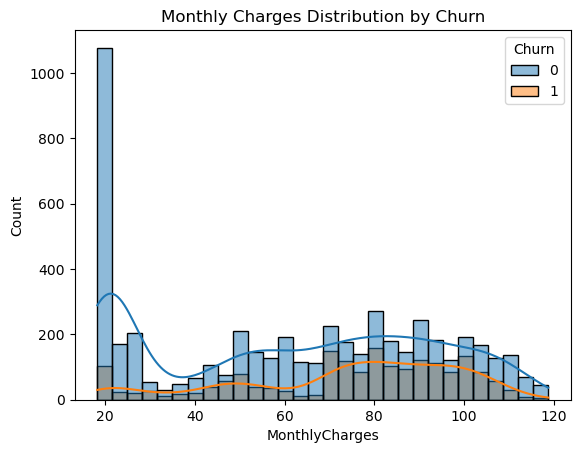

In [109]:
sns.histplot(data=df, x='MonthlyCharges', hue='Churn', kde=True, bins=30)
plt.title('Monthly Charges Distribution by Churn')
plt.show()

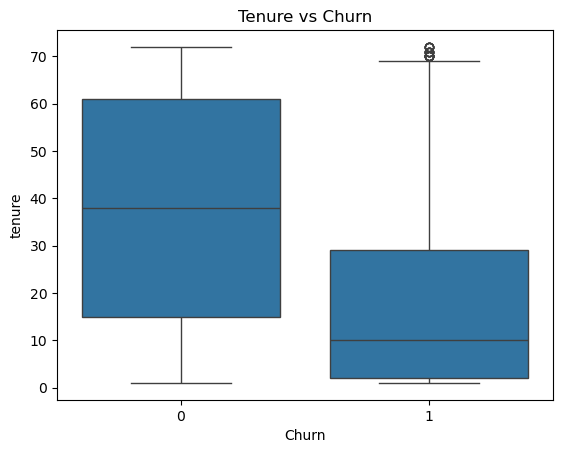

In [110]:
sns.boxplot(x='Churn', y='tenure', data=df)
plt.title('Tenure vs Churn')
plt.show()


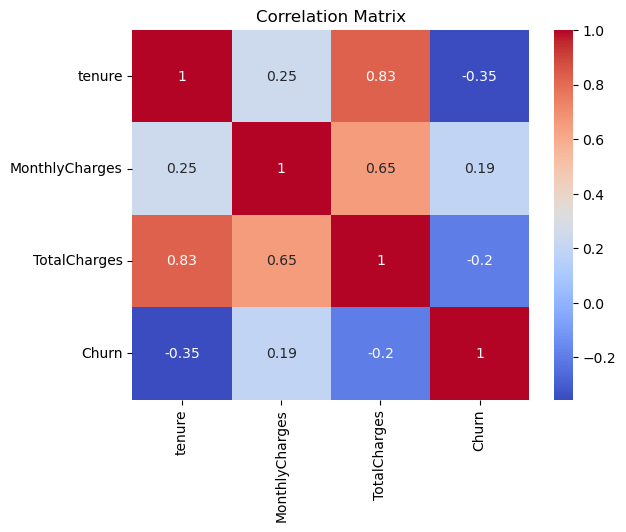

In [111]:
sns.heatmap(df[['tenure','MonthlyCharges','TotalCharges','Churn']].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()


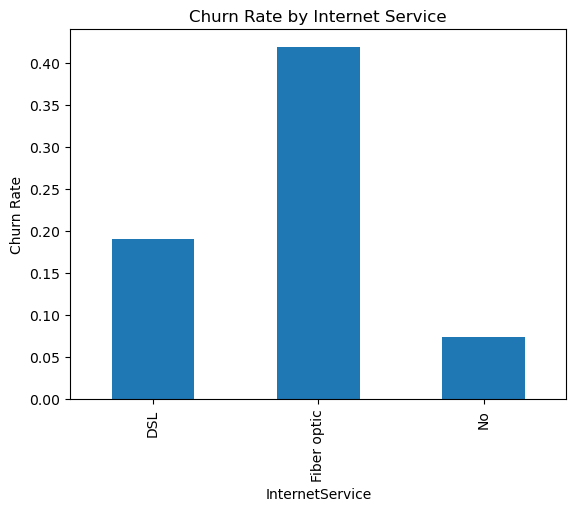

In [112]:
churn_rate = df.groupby('InternetService')['Churn'].mean()
churn_rate.plot(kind='bar')
plt.ylabel('Churn Rate')
plt.title('Churn Rate by Internet Service')
plt.show()


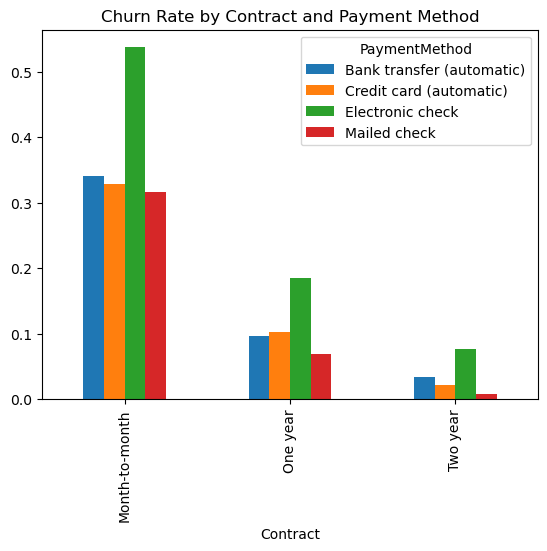

In [113]:
pd.crosstab(df['Contract'], df['PaymentMethod'], values=df['Churn'], aggfunc='mean').plot(kind='bar')
plt.title('Churn Rate by Contract and Payment Method')
plt.show()

In [114]:
categorical_cols = df.select_dtypes(include=['object']).columns
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
print(df_encoded.info())
df_encoded.head()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 31 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   SeniorCitizen                          7032 non-null   int64  
 1   tenure                                 7032 non-null   int64  
 2   MonthlyCharges                         7032 non-null   float64
 3   TotalCharges                           7032 non-null   float64
 4   Churn                                  7032 non-null   int64  
 5   gender_Male                            7032 non-null   bool   
 6   Partner_Yes                            7032 non-null   bool   
 7   Dependents_Yes                         7032 non-null   bool   
 8   PhoneService_Yes                       7032 non-null   bool   
 9   MultipleLines_No phone service         7032 non-null   bool   
 10  MultipleLines_Yes                      7032 non-null   bool   
 11  InternetS

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,False,True,False,False,True,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,0,True,False,False,True,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,1,True,False,False,True,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,0,True,False,False,False,True,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,1,False,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False


In [115]:
from sklearn.model_selection import train_test_split

X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)
print("Training set churn proportion:")
print(y_train.value_counts(normalize=True))
print("\nTesting set churn proportion:")
print(y_test.value_counts(normalize=True))


Training set churn proportion:
Churn
0    0.734222
1    0.265778
Name: proportion, dtype: float64

Testing set churn proportion:
Churn
0    0.734186
1    0.265814
Name: proportion, dtype: float64


In [116]:
from sklearn.preprocessing import StandardScaler

num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen']

scaler = StandardScaler()


scaler.fit(X_train[num_cols])

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[num_cols] = scaler.transform(X_train[num_cols])
X_test_scaled[num_cols] = scaler.transform(X_test[num_cols])

print(X_train_scaled.head())
print(X_test_scaled.head())


      SeniorCitizen    tenure  MonthlyCharges  TotalCharges  gender_Male  \
1413      -0.439319  1.321816        0.981556      1.659900         True   
7003      -0.439319 -0.267410       -0.971546     -0.562252         True   
3355      -0.439319  1.444064        0.837066      1.756104        False   
4494      -0.439319 -1.204646        0.641092     -0.908326         True   
3541      -0.439319  0.669826       -0.808787     -0.101561        False   

      Partner_Yes  Dependents_Yes  PhoneService_Yes  \
1413         True            True              True   
7003        False           False             False   
3355         True           False              True   
4494        False           False              True   
3541         True           False             False   

      MultipleLines_No phone service  MultipleLines_Yes  ...  \
1413                           False               True  ...   
7003                            True              False  ...   
3355                

# Logistic Regression

In [117]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, recall_score, f1_score
logreg = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')

logreg.fit(X_train_scaled, y_train)

y_proba = logreg.predict_proba(X_test_scaled)[:, 1]

best_thresh = 0
best_f1 = 0

for t in [i/100 for i in range(20, 80)]:  
    preds = (y_proba >= t).astype(int)
    f1 = f1_score(y_test, preds)
    
    if f1 > best_f1:
        best_f1 = f1
        best_thresh = t

print(f"Best Threshold: {best_thresh:.2f}")
y_pred = (y_proba >= best_thresh).astype(int)

accuracy = accuracy_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

print(f"\nAccuracy on test set: {accuracy:.4f}")
print(f"Recall (Churn): {recall:.4f}")
print(f"F1 Score: {best_f1:.4f}\n")

print("Confusion Matrix:\n", conf_matrix)
print("\nClassification Report:\n", class_report)

Best Threshold: 0.63

Accuracy on test set: 0.7768
Recall (Churn): 0.6952
F1 Score: 0.6235

Confusion Matrix:
 [[833 200]
 [114 260]]

Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.81      0.84      1033
           1       0.57      0.70      0.62       374

    accuracy                           0.78      1407
   macro avg       0.72      0.75      0.73      1407
weighted avg       0.80      0.78      0.78      1407



In [118]:
coeffs = logreg.coef_[0]  
features = X_train_scaled.columns

coef_df = pd.DataFrame({
    "Feature": features,
    "Coefficient": coeffs,
    "Odds_Ratio": np.exp(coeffs)
})

coef_df = coef_df.sort_values(by="Coefficient", ascending=False)

print(coef_df.head(10))
print(coef_df.tail(10))


                                  Feature  Coefficient  Odds_Ratio
10            InternetService_Fiber optic     1.125391    3.081422
3                            TotalCharges     0.610057    1.840537
28         PaymentMethod_Electronic check     0.418495    1.519673
21                        StreamingTV_Yes     0.382479    1.465914
23                    StreamingMovies_Yes     0.367871    1.444655
9                       MultipleLines_Yes     0.335754    1.398995
26                   PaperlessBilling_Yes     0.258044    1.294396
27  PaymentMethod_Credit card (automatic)     0.079969    1.083253
0                           SeniorCitizen     0.076025    1.078989
17                   DeviceProtection_Yes     0.069509    1.071981
                                 Feature  Coefficient  Odds_Ratio
11                    InternetService_No    -0.169810    0.843825
16  DeviceProtection_No internet service    -0.169810    0.843825
6                         Dependents_Yes    -0.227448    0.796564

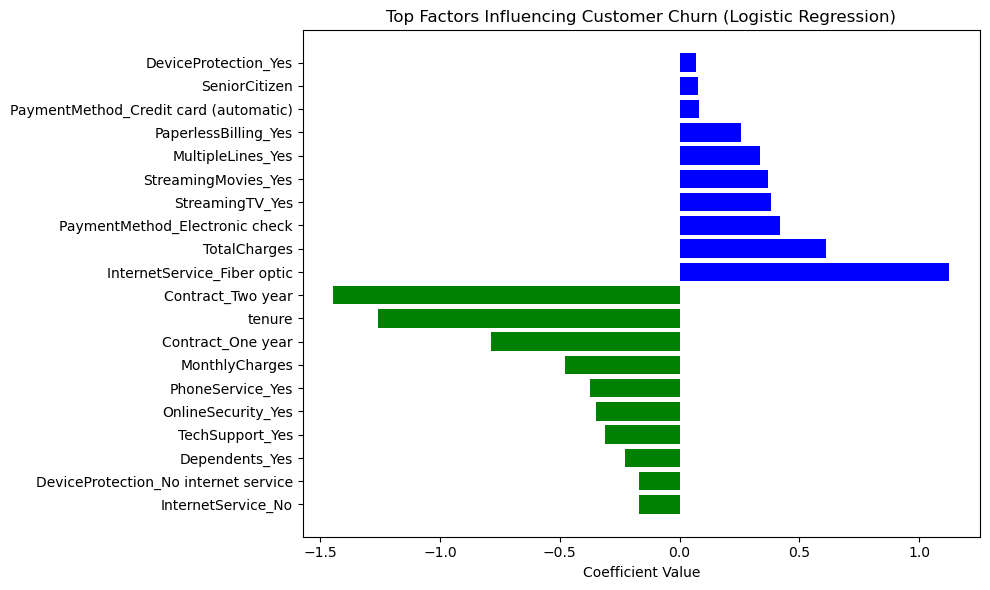

In [119]:
import matplotlib.pyplot as plt

top_positive = coef_df.head(10)
top_negative = coef_df.tail(10)

plt.figure(figsize=(10,6))

plt.barh(top_negative["Feature"], top_negative["Coefficient"], color="green")

plt.barh(top_positive["Feature"], top_positive["Coefficient"], color="blue")

plt.xlabel("Coefficient Value")
plt.title("Top Factors Influencing Customer Churn (Logistic Regression)")
plt.tight_layout()
plt.show()


In [120]:
#Longest tenure and longer contracts are the strongest protective factors.
#Phone service, tech support, and online security also reduce churn.
#Customers without dependents or additional services are slightly less likely to leave.
#High-risk customers: Fiber optic users, those paying via electronic check, subscribers of streaming services, and paperless billing users.
#Low-risk customers: Long-tenure customers, those on one- or two-year contracts, phone service users, and tech support subscribers.
#Actionable: Target high-risk groups for retention campaigns, bundle services, or offer incentives to reduce churn.

# Decision Tree

In [121]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, recall_score, f1_score, confusion_matrix, classification_report
dt_unconstrained = DecisionTreeClassifier(
    criterion='entropy',
    random_state=42,
    class_weight='balanced'   
)

dt_unconstrained.fit(X_train_scaled, y_train)

y_proba_un = dt_unconstrained.predict_proba(X_test_scaled)[:,1]
y_pred_un = (y_proba_un >= 0.6).astype(int)  

print("Unconstrained Decision Tree:")
print("Accuracy:", accuracy_score(y_test, y_pred_un))
print("Recall:", recall_score(y_test, y_pred_un))
print("F1 Score:", f1_score(y_test, y_pred_un))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_un))

dt_pruned = DecisionTreeClassifier(
    criterion='entropy',
    max_depth=5,
    min_samples_leaf=5,
    random_state=42,
    class_weight='balanced'  
)

dt_pruned.fit(X_train_scaled, y_train)

y_proba_pr = dt_pruned.predict_proba(X_test_scaled)[:,1]
y_pred_pr = (y_proba_pr >= 0.6).astype(int) 

print("\nPruned Decision Tree:")
print("Accuracy:", accuracy_score(y_test, y_pred_pr))
print("Recall:", recall_score(y_test, y_pred_pr))
print("F1 Score:", f1_score(y_test, y_pred_pr))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_pr))
print("\nClassification Report:\n", classification_report(y_test, y_pred_pr))

Unconstrained Decision Tree:
Accuracy: 0.7263681592039801
Recall: 0.46524064171123
F1 Score: 0.4747612551159618
Confusion Matrix:
 [[848 185]
 [200 174]]

Pruned Decision Tree:
Accuracy: 0.775408670931059
Recall: 0.6470588235294118
F1 Score: 0.605
Confusion Matrix:
 [[849 184]
 [132 242]]

Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.82      0.84      1033
           1       0.57      0.65      0.60       374

    accuracy                           0.78      1407
   macro avg       0.72      0.73      0.72      1407
weighted avg       0.79      0.78      0.78      1407



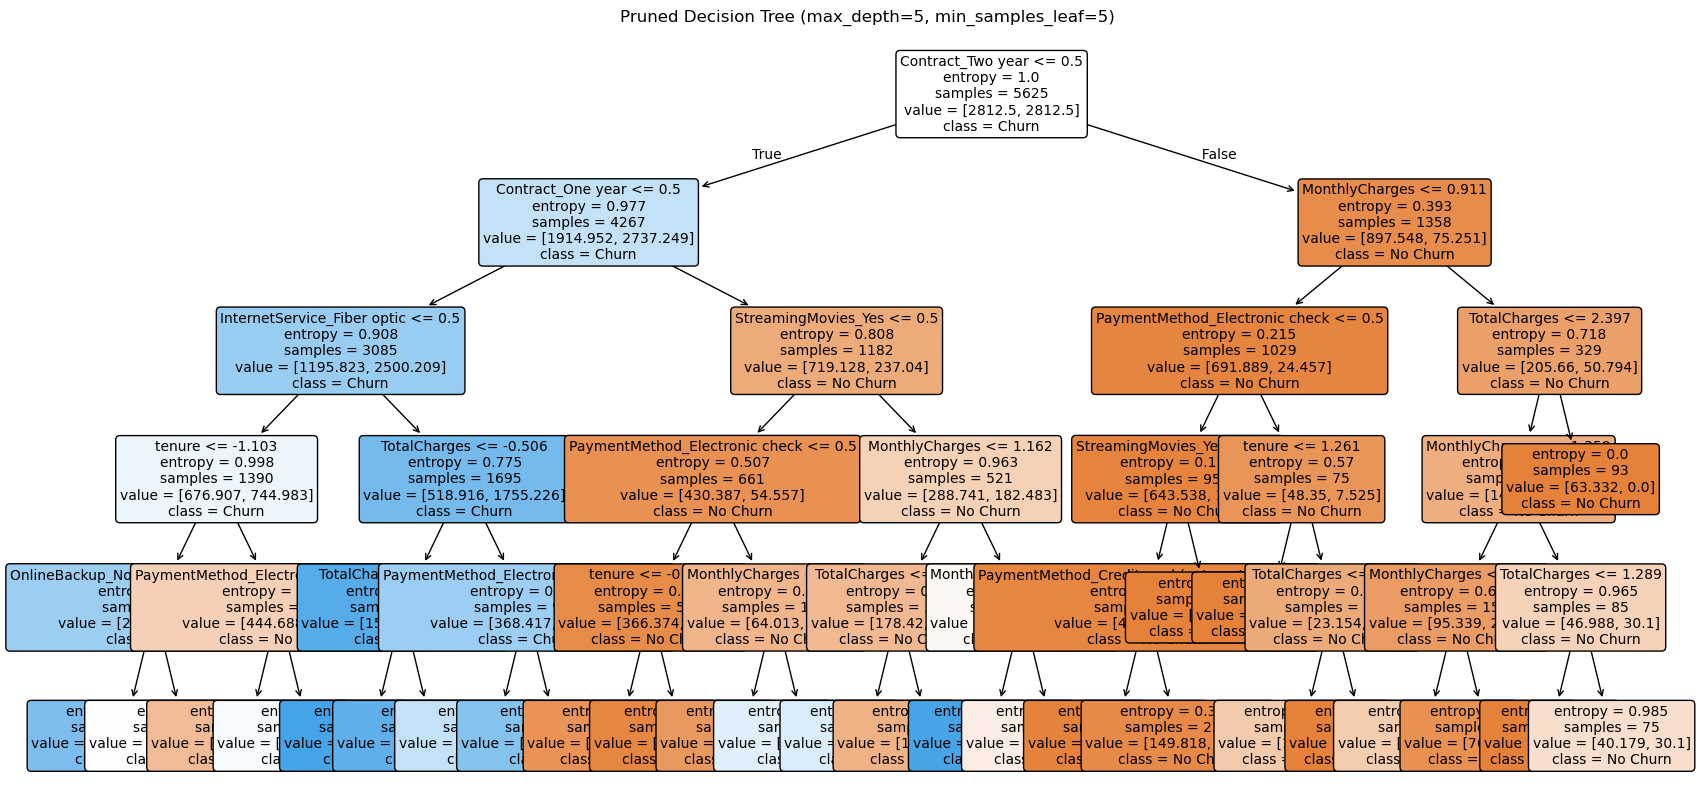

In [122]:
from sklearn import tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20,10))
tree.plot_tree(
    dt_pruned,                   
    feature_names=X_train_scaled.columns,
    class_names=['No Churn', 'Churn'],
    filled=True,                  
    rounded=True,                  
    fontsize=10
)
plt.title("Pruned Decision Tree (max_depth=5, min_samples_leaf=5)")
plt.show()


# Random Forest Classifier

In [123]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
rf = RandomForestClassifier(
    n_estimators=200,   
    criterion='entropy',  
    max_depth=8,    
    min_samples_leaf=5, 
    class_weight='balanced', 
    random_state=42
)
rf.fit(X_train_scaled, y_train)
train_acc_rf = rf.score(X_train_scaled, y_train)
y_proba_rf = rf.predict_proba(X_test_scaled)[:, 1]
best_threshold = 0.6
y_pred_rf = (y_proba_rf >= best_threshold).astype(int)
test_acc_rf = accuracy_score(y_test, y_pred_rf)
conf_matrix_rf = confusion_matrix(y_test, y_pred_rf)
class_report_rf = classification_report(y_test, y_pred_rf)
print(f"Random Forest Classifier (Bagging) with threshold {best_threshold}:")
print("Training Accuracy:", train_acc_rf)
print("Testing Accuracy :", test_acc_rf)
print("\nConfusion Matrix:\n", conf_matrix_rf)
print("\nClassification Report:\n", class_report_rf)

Random Forest Classifier (Bagging) with threshold 0.6:
Training Accuracy: 0.7905777777777778
Testing Accuracy : 0.7874911158493249

Confusion Matrix:
 [[855 178]
 [121 253]]

Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.83      0.85      1033
           1       0.59      0.68      0.63       374

    accuracy                           0.79      1407
   macro avg       0.73      0.75      0.74      1407
weighted avg       0.80      0.79      0.79      1407



# XgBoost

In [124]:
import xgboost as xgb
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, log_loss
xgb_clf = xgb.XGBClassifier(
    objective='binary:logistic',     
    eval_metric='logloss',      
    n_estimators=200,     
    max_depth=5,         
    learning_rate=0.1,       
    scale_pos_weight=(len(y_train) - sum(y_train)) / sum(y_train),
    random_state=42,
    use_label_encoder=False
)

xgb_clf.fit(X_train_scaled, y_train)
y_pred_proba = xgb_clf.predict_proba(X_test_scaled)[:, 1]
best_threshold = 0.6
y_pred = (y_pred_proba >= best_threshold).astype(int)
train_acc_xgb = xgb_clf.score(X_train_scaled, y_train)
test_acc_xgb = accuracy_score(y_test, y_pred)
logloss_xgb = log_loss(y_test, y_pred_proba)
conf_matrix_xgb = confusion_matrix(y_test, y_pred)
class_report_xgb = classification_report(y_test, y_pred)
print(f"XGBoost Classifier (Boosting) with threshold {best_threshold}:")
print("Training Accuracy:", train_acc_xgb)
print("Testing Accuracy :", test_acc_xgb)
print("Logarithmic Loss  :", logloss_xgb)
print("\nConfusion Matrix:\n", conf_matrix_xgb)
print("\nClassification Report:\n", class_report_xgb)

C:\Users\HP\AppData\Roaming\Python\Python313\site-packages\xgboost\training.py:199: UserWarning: [22:41:42] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost Classifier (Boosting) with threshold 0.6:
Training Accuracy: 0.8524444444444444
Testing Accuracy : 0.7718550106609808
Logarithmic Loss  : 0.49963911262735977

Confusion Matrix:
 [[835 198]
 [123 251]]

Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.81      0.84      1033
           1       0.56      0.67      0.61       374

    accuracy                           0.77      1407
   macro avg       0.72      0.74      0.72      1407
weighted avg       0.79      0.77      0.78      1407



In [125]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt

y_pred_log = logreg.predict(X_test_scaled)
y_proba_log = logreg.predict_proba(X_test_scaled)[:,1]


y_pred_dt = dt_pruned.predict(X_test_scaled)
y_proba_dt = dt_pruned.predict_proba(X_test_scaled)[:,1]



y_pred_rf = rf.predict(X_test_scaled)
y_proba_rf = rf.predict_proba(X_test_scaled)[:,1]


y_pred_xgb = (xgb_clf.predict_proba(X_test_scaled)[:,1] >= 0.5).astype(int)
y_proba_xgb = xgb_clf.predict_proba(X_test_scaled)[:,1]


In [126]:
y_pred_log = (logreg.predict_proba(X_test_scaled)[:,1] >= 0.63).astype(int)
y_pred_dt = (dt_pruned.predict_proba(X_test_scaled)[:,1] >= 0.6).astype(int)
y_pred_rf = (rf.predict_proba(X_test_scaled)[:,1] >= 0.6).astype(int)
y_pred_xgb = (xgb_clf.predict_proba(X_test_scaled)[:,1] >= 0.6).astype(int)

models = ['Logistic Regression', 'Pruned Decision Tree', 'Random Forest', 'XGBoost']
preds = [y_pred_log, y_pred_dt, y_pred_rf, y_pred_xgb]

comparison = []

for model_name, y_pred in zip(models, preds):
    comparison.append({
        'Model': model_name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred)
    })

comparison_df = pd.DataFrame(comparison)
print(comparison_df)

                  Model  Accuracy  Precision    Recall  F1-Score
0   Logistic Regression  0.776830   0.565217  0.695187  0.623501
1  Pruned Decision Tree  0.775409   0.568075  0.647059  0.605000
2         Random Forest  0.787491   0.587007  0.676471  0.628571
3               XGBoost  0.771855   0.559020  0.671123  0.609964


Model with highest Recall: Logistic Regression


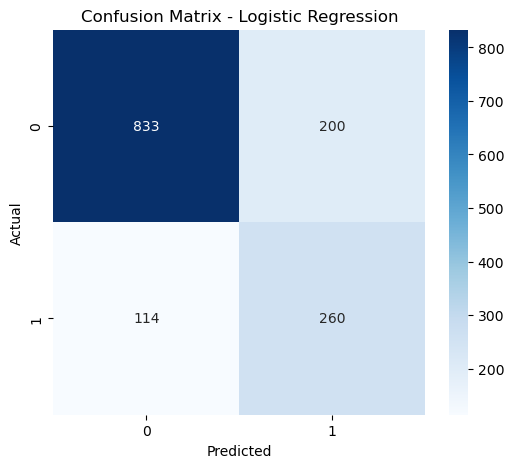

In [127]:
best_model_name = comparison_df.loc[comparison_df['Recall'].idxmax(), 'Model']
print(f"Model with highest Recall: {best_model_name}")

best_pred = {
    'Logistic Regression': y_pred_log,
    'Pruned Decision Tree': y_pred_dt,
    'Random Forest': y_pred_rf,
    'XGBoost': y_pred_xgb
}[best_model_name]

conf_matrix_best = confusion_matrix(y_test, best_pred)

import seaborn as sns
plt.figure(figsize=(6,5))
sns.heatmap(conf_matrix_best, annot=True, fmt='d', cmap='Blues')
plt.title(f'Confusion Matrix - {best_model_name}')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


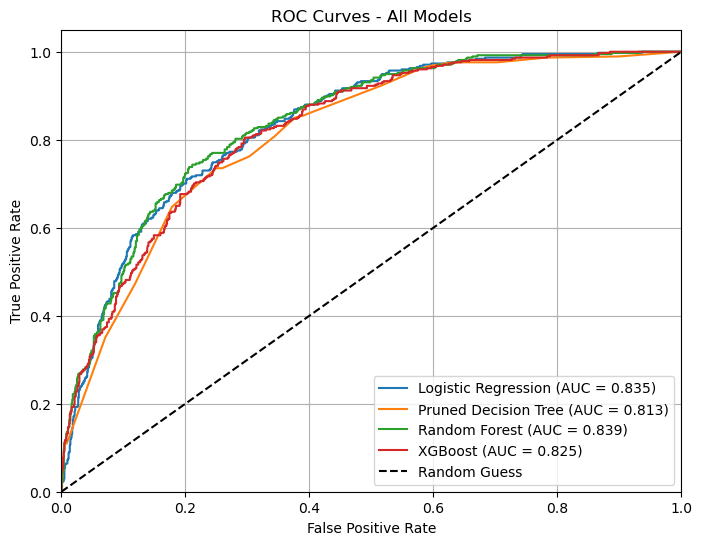

In [128]:
plt.figure(figsize=(8,6))

y_probas = [y_proba_log, y_proba_dt, y_proba_rf, y_proba_xgb]

for model_name, y_proba in zip(models, y_probas):
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{model_name} (AUC = {roc_auc:.3f})')

plt.plot([0,1], [0,1], 'k--', label='Random Guess')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves - All Models')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()


## Conclusion: Customer Churn Analysis

- Dataset cleaned and prepared: numeric conversion, missing values removed, categorical variables encoded.
- Customers with long tenure or long-term contracts are less likely to churn.
- High-risk customers: Fiber optic users, paperless billing, streaming service subscribers, electronic check payments.
- Models tested: Logistic Regression, Decision Tree, Random Forest, XGBoost.
- Logistic Regression performed best for catching churners (highest recall ~70%).
- Recommendation: Focus retention strategies on high-risk groups to reduce churn.